<a href="https://colab.research.google.com/github/FatiBuuloloo/Customer_Churn_Prediction_using_Deep_Learning-mini_project_001/blob/main/bank_churn_classification_ann_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 001

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score, classification_report, average_precision_score, precision_recall_curve, auc
import tensorflow as tf
from keras import regularizers
from keras.callbacks import EarlyStopping,ReduceLROnPlateau
from tensorflow import keras

In [2]:
url = "https://github.com/FatiBuuloloo/Customer_Churn_Prediction_using_Deep_Learning-mini_project_001/releases/download/Dataset/friance_new.csv"
data = pd.read_csv(url)
data.columns

/tmp/ipykernel_20734/3032465476.py:2: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(url)


Index(['Surname', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited',
       'Surname_tfidf_0', 'Surname_tfidf_1', 'Surname_tfidf_2',
       'Surname_tfidf_3', 'Surname_tfidf_4', 'France', 'Germany', 'Spain',
       'Female', 'Male', 'Mem__no__Products', 'Cred_Bal_Sal', 'Bal_sal',
       'Tenure_Age', 'Age_Tenure_product'],
      dtype='object')

In [3]:
data.shape

(175028, 25)

In [4]:
data.isnull().sum()

,0
Surname,0
CreditScore,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0
Exited,0


In [5]:
data.dropna(inplace=True)

In [6]:
data.head(5)

,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,...,France,Germany,Spain,Female,Male,Mem__no__Products,Cred_Bal_Sal,Bal_sal,Tenure_Age,Age_Tenure_product
0,2023,668.0,33.0,3.0,0.00,2.0,1,0,181449.97,0,...,1,0,0,0,1,0.0,0.0,0.0,"9.090.909.090.909.090,00",99.0
1,2024,627.0,33.0,1.0,0.00,2.0,1,1,49503.5,0,...,1,0,0,0,1,2.0,0.0,0.0,"30.303.030.303.030.300,00",33.0
2,1236,678.0,40.0,10.0,0.00,2.0,1,0,184866.69,0,...,1,0,0,0,1,0.0,0.0,0.0,0.25,400.0
3,1362,581.0,34.0,2.0,148882.54,1.0,1,1,84560.88,0,...,1,0,0,0,1,1.0,"10.229.405.812.711.500,00","17.606.550.452.171.200,00","58.823.529.411.764.700,00",68.0
4,491,716.0,33.0,5.0,0.00,2.0,1,1,15068.83,0,...,0,0,1,0,1,2.0,0.0,0.0,"15.151.515.151.515.100,00",165.0


In [7]:
data.columns

Index(['Surname', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited',
       'Surname_tfidf_0', 'Surname_tfidf_1', 'Surname_tfidf_2',
       'Surname_tfidf_3', 'Surname_tfidf_4', 'France', 'Germany', 'Spain',
       'Female', 'Male', 'Mem__no__Products', 'Cred_Bal_Sal', 'Bal_sal',
       'Tenure_Age', 'Age_Tenure_product'],
      dtype='object')

In [8]:
col_to_drop = ['Surname','Surname_tfidf_0', 'Surname_tfidf_1', 'Surname_tfidf_2','Surname_tfidf_3', 'Surname_tfidf_4','Spain', 'France', 'Germany','Mem__no__Products', 'Cred_Bal_Sal', 'Bal_sal','Tenure_Age', 'Age_Tenure_product']
data.drop(columns=col_to_drop,inplace=True)

In [9]:
data.shape

(175028, 11)

In [10]:
data.head(5)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,668.0,33.0,3.0,0.00,2.0,1,0,181449.97,0,0,1
1,627.0,33.0,1.0,0.00,2.0,1,1,49503.5,0,0,1
2,678.0,40.0,10.0,0.00,2.0,1,0,184866.69,0,0,1
3,581.0,34.0,2.0,148882.54,1.0,1,1,84560.88,0,0,1
4,716.0,33.0,5.0,0.00,2.0,1,1,15068.83,0,0,1


In [11]:
data[data.Balance==0]

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,668.0,33.0,3.0,0.0,2.0,1,0,181449.97,0,0,1
1,627.0,33.0,1.0,0.0,2.0,1,1,49503.5,0,0,1
2,678.0,40.0,10.0,0.0,2.0,1,0,184866.69,0,0,1
4,716.0,33.0,5.0,0.0,2.0,1,1,15068.83,0,0,1
8,676.0,43.0,4.0,0.0,2.0,1,0,142917.13,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
175019,841.0,28.0,4.0,0.0,2.0,1,1,179436.6,0,0,1
175022,726.0,36.0,2.0,0.0,1.0,1,0,195192.4,0,0,1
175024,800.0,29.0,2.0,0.0,2.0,0,0,167773.55,0,1,0
175025,771.0,39.0,5.0,0.0,2.0,1,0,96270.64,0,0,1


In [12]:
data.columns

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Female', 'Male'],
      dtype='object')

In [13]:
data['EstimatedSalary'] = pd.to_numeric(data['EstimatedSalary'], errors='coerce')
data['EstimatedSalary'].isna().sum()

np.int64(2)

In [14]:
data.dropna(inplace=True)

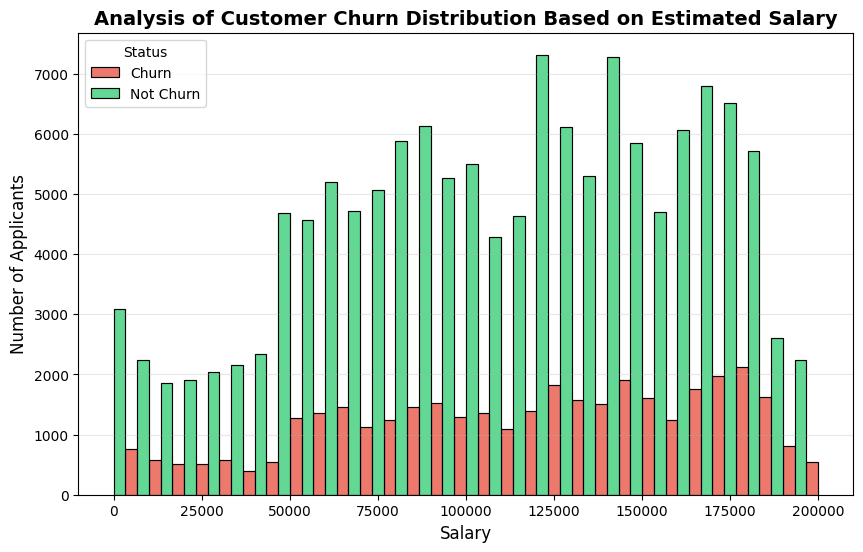

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x="EstimatedSalary", hue="Exited", multiple="dodge", palette={1: "#e74c3c", 0: "#2ecc71"}, bins=30)

plt.title("Analysis of Customer Churn Distribution Based on Estimated Salary", fontsize=14, fontweight='bold')
plt.xlabel("Salary", fontsize=12)
plt.ylabel("Number of Applicants", fontsize=12)
plt.legend(title="Status", labels=["Churn", "Not Churn"])
plt.grid(axis='y', alpha=0.3)
plt.show()

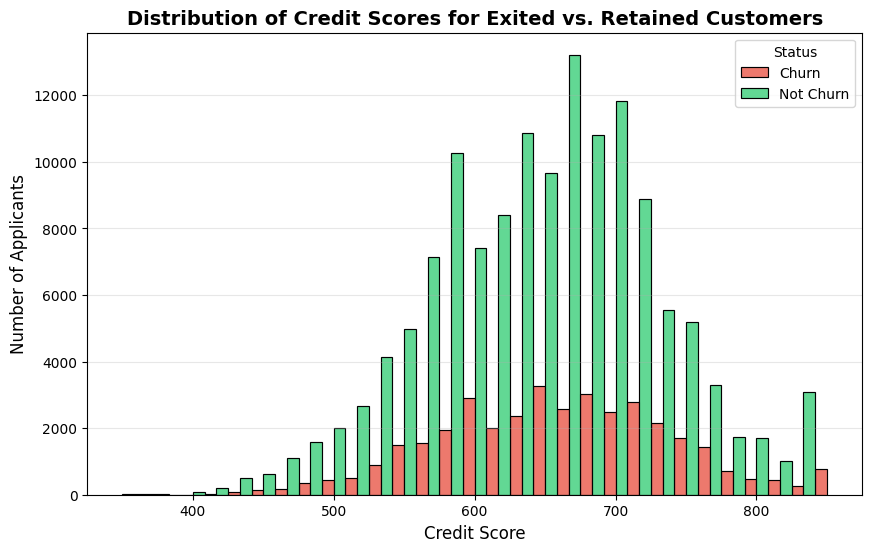

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x="CreditScore", hue="Exited", multiple="dodge", palette={1: "#e74c3c", 0: "#2ecc71"}, bins=30)

plt.title("Distribution of Credit Scores for Exited vs. Retained Customers", fontsize=14, fontweight='bold')
plt.xlabel("Credit Score", fontsize=12)
plt.ylabel("Number of Applicants", fontsize=12)
plt.legend(title="Status", labels=["Churn", "Not Churn"])
plt.grid(axis='y', alpha=0.3)
plt.show()

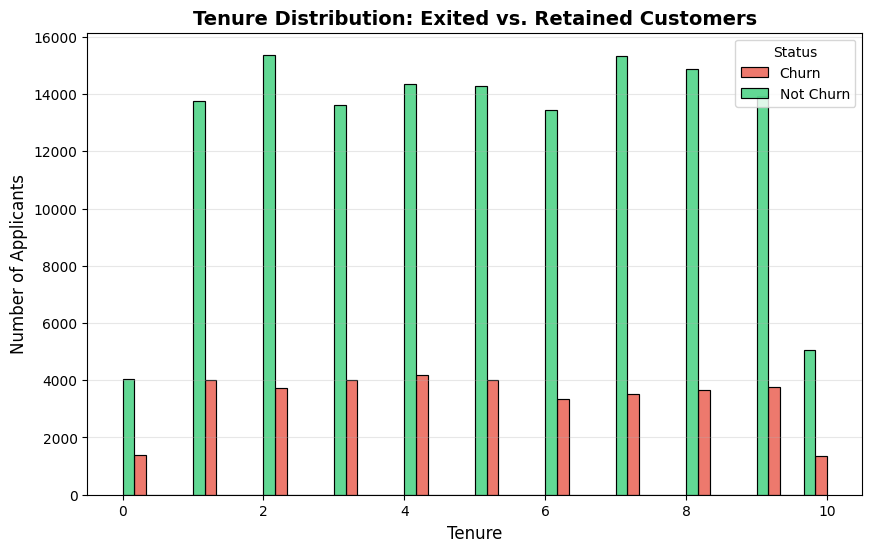

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x="Tenure", hue="Exited", multiple="dodge", palette={1: "#e74c3c", 0: "#2ecc71"}, bins=30)

plt.title("Tenure Distribution: Exited vs. Retained Customers", fontsize=14, fontweight='bold')
plt.xlabel("Tenure", fontsize=12)
plt.ylabel("Number of Applicants", fontsize=12)
plt.legend(title="Status", labels=["Churn", "Not Churn"])
plt.grid(axis='y', alpha=0.3)
plt.show()

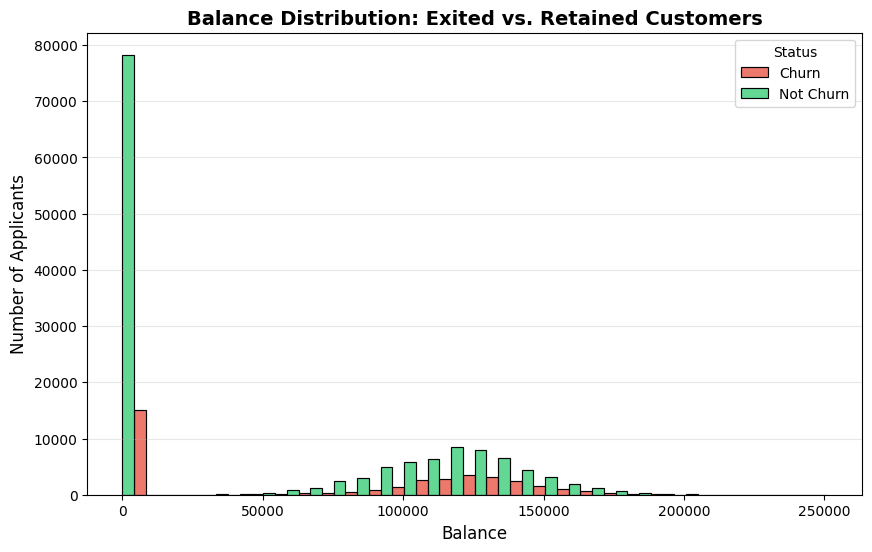

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x="Balance", hue="Exited", multiple="dodge", palette={1: "#e74c3c", 0: "#2ecc71"}, bins=30)

plt.title("Balance Distribution: Exited vs. Retained Customers", fontsize=14, fontweight='bold')
plt.xlabel("Balance", fontsize=12)
plt.ylabel("Number of Applicants", fontsize=12)
plt.legend(title="Status", labels=["Churn", "Not Churn"])
plt.grid(axis='y', alpha=0.3)
plt.show()

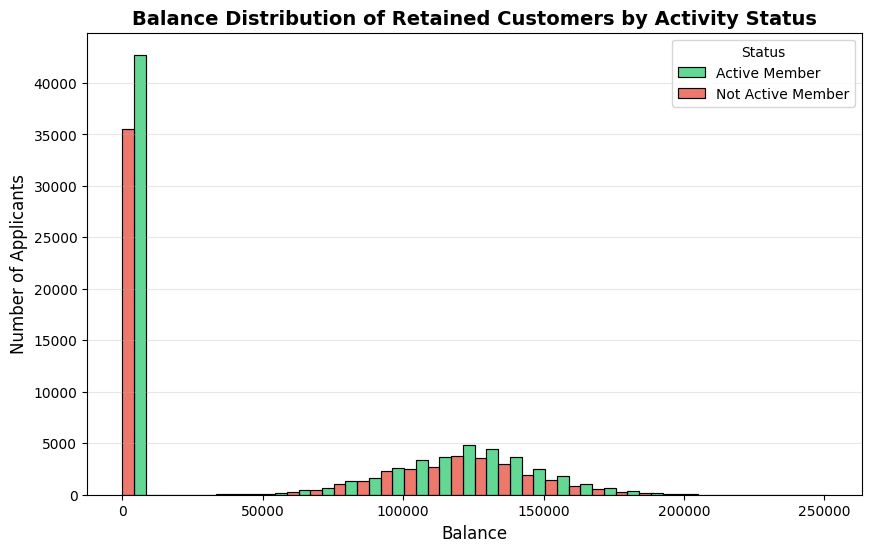

In [19]:
data_not_exit = data[data.Exited==0]
plt.figure(figsize=(10, 6))
sns.histplot(data=data_not_exit, x="Balance", hue="IsActiveMember", multiple="dodge", palette={0: "#e74c3c", 1: "#2ecc71"}, bins=30)

plt.title("Balance Distribution of Retained Customers by Activity Status", fontsize=14, fontweight='bold')
plt.xlabel("Balance", fontsize=12)
plt.ylabel("Number of Applicants", fontsize=12)
plt.legend(title="Status", labels=["Active Member", "Not Active Member"])
plt.grid(axis='y', alpha=0.3)
plt.show()

In [20]:
data.columns

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Female', 'Male'],
      dtype='object')

In [21]:
data["Prod_per_Tenure"] = data["NumOfProducts"]/(data["Tenure"]+1)
data["Balance_per_product"] = data["Balance"]/(data["NumOfProducts"]+1)
data["Age_non_active"] =data.Age*(1-data.IsActiveMember)
data["Credit_per_tenure"] = data["CreditScore"]/(data.Tenure+1)

In [22]:
key_features = ['Balance', 'EstimatedSalary', 'CreditScore', 'Age', 'NumOfProducts', 'IsActiveMember']
overlap_check = data.groupby(key_features)['Exited'].agg(['mean', 'count'])
ambiguous_data = overlap_check[(overlap_check['count'] > 1) &(overlap_check['mean'] > 0) &(overlap_check['mean'] < 1)]
print(f"Found {len(ambiguous_data)} profiles that have the Churn and Stay labels simultaneously.")

Found 1645 profiles that have the Churn and Stay labels simultaneously.


In [23]:
data_with_overlap = data.merge(ambiguous_data.reset_index()[key_features],on=key_features,how='left',indicator=True)
data_cleaned = data_with_overlap[data_with_overlap['_merge'] == 'left_only'].drop(columns=['_merge'])

In [24]:
data

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male,Prod_per_Tenure,Balance_per_product,Age_non_active,Credit_per_tenure
0,668.0,33.0,3.0,0.00,2.0,1,0,181449.97,0,0,1,0.500000,0.000,33.0,167.000000
1,627.0,33.0,1.0,0.00,2.0,1,1,49503.50,0,0,1,1.000000,0.000,0.0,313.500000
2,678.0,40.0,10.0,0.00,2.0,1,0,184866.69,0,0,1,0.181818,0.000,40.0,61.636364
3,581.0,34.0,2.0,148882.54,1.0,1,1,84560.88,0,0,1,0.333333,74441.270,0.0,193.666667
4,716.0,33.0,5.0,0.00,2.0,1,1,15068.83,0,0,1,0.333333,0.000,0.0,119.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175023,644.0,28.0,7.0,155060.41,1.0,1,0,29179.52,0,0,1,0.125000,77530.205,28.0,80.500000
175024,800.0,29.0,2.0,0.00,2.0,0,0,167773.55,0,1,0,0.666667,0.000,29.0,266.666667
175025,771.0,39.0,5.0,0.00,2.0,1,0,96270.64,0,0,1,0.333333,0.000,39.0,128.500000
175026,516.0,35.0,10.0,57369.61,1.0,1,1,101699.77,0,0,1,0.090909,28684.805,0.0,46.909091


In [25]:
df_X = data_cleaned.drop(columns=["Exited"])
df_y = data_cleaned["Exited"]

In [26]:
print(df_X.isna().sum())
print(df_y.isna().sum())

CreditScore            0
Age                    0
Tenure                 0
Balance                0
NumOfProducts          0
HasCrCard              0
IsActiveMember         0
EstimatedSalary        0
Female                 0
Male                   0
Prod_per_Tenure        0
Balance_per_product    0
Age_non_active         0
Credit_per_tenure      0
dtype: int64
0


In [27]:
train1_X, test1_X, train_y, test1_y = train_test_split(df_X, df_y, test_size=0.3, random_state=24, stratify=df_y)
val1_X, test_X, val_y, test_y = train_test_split(test1_X, test1_y, test_size=0.2, random_state=24, stratify=test1_y)

In [28]:
not_be_scaled=['HasCrCard','IsActiveMember', 'Exited', 'Female', 'Male']

In [29]:
cols_to_scale = []
for item in data.columns:
    if item not in not_be_scaled:
        cols_to_scale.append(item)

In [30]:
scaler=StandardScaler()
train1_X[cols_to_scale] = scaler.fit_transform(train1_X[cols_to_scale])
val1_X[cols_to_scale] = scaler.transform(val1_X[cols_to_scale])
test_X[cols_to_scale] = scaler.transform(test_X[cols_to_scale])

In [32]:
from imblearn.under_sampling import TomekLinks
tl = TomekLinks(sampling_strategy='all')
X_res, y_res = tl.fit_resample(train1_X, train_y)

# Bangun Model

In [33]:
model = keras.Sequential([
keras.layers.Dense(128, input_shape=(X_res.shape[1],),activation="tanh"),
keras.layers.Dropout(0.3),
keras.layers.Dense(100, activation="tanh"),
keras.layers.Dropout(0.2),
keras.layers.Dense(64, activation="tanh",kernel_regularizer=regularizers.l2(0.02)),
keras.layers.Dropout(0.1),
keras.layers.Dense(1,activation="sigmoid")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.2,
    patience=5,
    min_lr=0.00001,
    verbose=1)
earlystop=EarlyStopping(monitor='val_loss',patience=10)

In [35]:
METRICS = [
    keras.metrics.BinaryAccuracy(name='accuracy'),
    keras.metrics.Precision(name='precision'),
    keras.metrics.Recall(name='recall'),
    keras.metrics.AUC(name='auc'),
]
model.compile(optimizer="rmsprop",loss="binary_crossentropy",metrics=METRICS)

In [36]:
def score1(true, predict):
    print(f"Accuracy Score: {accuracy_score(true, predict)}")
    print(f"AUC Score: {roc_auc_score(true, predict)}")
    print(classification_report(true, predict))
    print()

In [37]:
class_weights={0:1,1:5}
history = model.fit(X_res,y_res,
epochs=50,batch_size=64,
validation_data=(val1_X,val_y),
class_weight=class_weights,
callbacks=[reduce_lr,earlystop]
)

Epoch 1/50
1677/1677 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8199 - auc: 0.8974 - loss: 0.7985 - precision: 0.4855 - recall: 0.8165 - val_accuracy: 0.8108 - val_auc: 0.8795 - val_loss: 0.4348 - val_precision: 0.5272 - val_recall: 0.7678 - learning_rate: 0.0010
Epoch 2/50
1677/1677 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8362 - auc: 0.9121 - loss: 0.6476 - precision: 0.5143 - recall: 0.8281 - val_accuracy: 0.8115 - val_auc: 0.8830 - val_loss: 0.4182 - val_precision: 0.5283 - val_recall: 0.7705 - learning_rate: 0.0010
Epoch 3/50
1677/1677 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8397 - auc: 0.9149 - loss: 0.6355 - precision: 0.5209 - recall: 0.8303 - val_accuracy: 0.8444 - val_auc: 0.8824 - val_loss: 0.3778 - val_precision: 0.6064 - val_recall: 0.6912 - learning_rate: 0.0010
Epoch 4/50
1677/1677 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8402 - auc: 0.9158 - loss: 0.6317 - precision: 0.5220 - recall: 0.8288 - val_accuracy: 0.8273 - val_auc: 0.8805 - val_loss: 0.4

In [38]:
prediction=model.predict(test_X)

321/321 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [39]:
prediction1 = np.where (prediction.flatten()>=0.7,1,0)
score1(test_y,prediction1)

Accuracy Score: 0.8681693989071039
AUC Score: 0.7839738865899515
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      8142
           1       0.69      0.64      0.67      2106

    accuracy                           0.87     10248
   macro avg       0.80      0.78      0.79     10248
weighted avg       0.86      0.87      0.87     10248




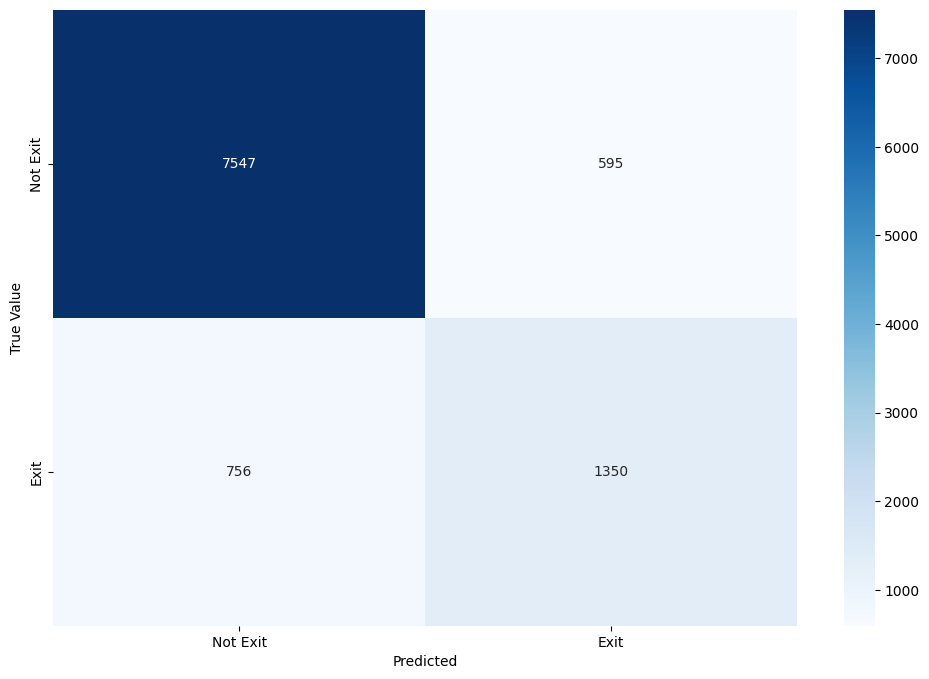

In [40]:
label=["Not Exit", "Exit"]
cm_model = confusion_matrix(test_y, prediction1)
plt.figure(figsize=(12,8))
sns.heatmap(cm_model, annot=True, fmt='d', cmap='Blues',
  xticklabels = label,
yticklabels = label)
plt.xlabel('Predicted')
plt.ylabel('True Value')
plt.show()

In [41]:
def calculate_rank_metrics(y_true, y_probs):
    roc_auc = roc_auc_score(y_true, y_probs)
    pr_auc = average_precision_score(y_true, y_probs)
    precision, recall, _ = precision_recall_curve(y_true, y_probs)
    pr_auc_val = auc(recall, precision)
    print(f"ROC-AUC Score      : {roc_auc:.4f}")
    print(f"PR-AUC (Avg Prec)  : {pr_auc:.4f}")
    print(f"PR-AUC (Trapezoid) : {pr_auc_val:.4f}")

In [42]:
calculate_rank_metrics(test_y, prediction.flatten())

ROC-AUC Score      : 0.8928
PR-AUC (Avg Prec)  : 0.7369
PR-AUC (Trapezoid) : 0.7368
